In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Cell 1: Setup, paths, data loading, and dataloaders.
import os, gc, json, time, random, shutil
from datetime import datetime
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup


project_root = '/content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1'
liar_data_dir = os.path.join(project_root, 'data', 'LIAR')
model_copy_dir = os.path.join(project_root, 'model_training', 'model_copy')
experiment_dir = os.path.join(project_root, 'model_training', 'liar_6label_to_3risk')
results_dir = os.path.join(project_root, 'model_training', 'liar_6label_to_3risk_results')
figure_dir = os.path.join(results_dir, 'figures')
for folder in [model_copy_dir, experiment_dir, results_dir, figure_dir]:
    os.makedirs(folder, exist_ok=True)

random_seed = 42
base_model_name = 'bert-base-uncased'
max_sequence_length = 128
batch_size = 16
max_epochs = 4
learning_rates = [1e-5, 2e-5, 3e-5]
resume_from_checkpoint = False
skip_finished_runs = True

six_label_names = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
risk_label_names = ['low_risk', 'medium_risk', 'high_risk']
six_label_map = {name: index for index, name in enumerate(six_label_names)}
six_to_risk_map = {'pants-fire': 2, 'false': 2, 'barely-true': 1, 'half-true': 1, 'mostly-true': 0, 'true': 0}
six_index_to_risk_index = np.array([2, 2, 1, 1, 0, 0])
selected_model_path = os.path.join(model_copy_dir, 'liar_6label_to_3risk_selected_model.pt')

def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

set_random_seed(random_seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

liar_columns = ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']

def load_liar_split(file_name):
    dataframe = pd.read_csv(os.path.join(liar_data_dir, file_name), sep='\t', header=None, names=liar_columns)
    dataframe = dataframe[['label', 'statement']].copy()
    dataframe['statement'] = dataframe['statement'].astype(str)
    dataframe['six_label'] = dataframe['label'].map(six_label_map)
    dataframe['risk_label'] = dataframe['label'].map(six_to_risk_map)
    dataframe = dataframe.dropna(subset=['six_label', 'risk_label']).copy()
    dataframe['six_label'] = dataframe['six_label'].astype(int)
    dataframe['risk_label'] = dataframe['risk_label'].astype(int)
    return dataframe

train_df = load_liar_split('train.tsv')
validation_df = load_liar_split('valid.tsv')
test_df = load_liar_split('test.tsv')

def distribution_row(dataframe, split_name, label_column, label_names):
    row = {'split': split_name, 'samples': len(dataframe)}
    counts = dataframe[label_column].value_counts().sort_index()
    for index, name in enumerate(label_names):
        row[name] = int(counts.get(index, 0))
    return row

six_dist_df = pd.DataFrame([distribution_row(train_df, 'train', 'six_label', six_label_names), distribution_row(validation_df, 'validation', 'six_label', six_label_names), distribution_row(test_df, 'test', 'six_label', six_label_names)])
risk_dist_df = pd.DataFrame([distribution_row(train_df, 'train', 'risk_label', risk_label_names), distribution_row(validation_df, 'validation', 'risk_label', risk_label_names), distribution_row(test_df, 'test', 'risk_label', risk_label_names)])
six_dist_df.to_csv(os.path.join(results_dir, 'table_01_six_label_distribution.csv'), index=False)
risk_dist_df.to_csv(os.path.join(results_dir, 'table_02_risk_label_distribution.csv'), index=False)

tokenizer = BertTokenizer.from_pretrained(base_model_name)

class LiarSixDataset(Dataset):
    def __init__(self, dataframe):
        self.statements = dataframe['statement'].astype(str).tolist()
        self.labels = dataframe['six_label'].astype(int).tolist()
    def __len__(self):
        return len(self.statements)
    def __getitem__(self, index):
        encoded = tokenizer(self.statements[index], truncation=True, padding='max_length', max_length=max_sequence_length, return_tensors='pt')
        return {'input_ids': encoded['input_ids'].squeeze(0), 'attention_mask': encoded['attention_mask'].squeeze(0), 'labels': torch.tensor(self.labels[index], dtype=torch.long)}

train_loader = DataLoader(LiarSixDataset(train_df), batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(LiarSixDataset(validation_df), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(LiarSixDataset(test_df), batch_size=batch_size, shuffle=False)

print('Device:', device)
display(six_dist_df)
display(risk_dist_df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device: cuda


,split,samples,pants-fire,false,barely-true,half-true,mostly-true,true
0,train,10240,839,1995,1654,2114,1962,1676
1,validation,1284,116,263,237,248,251,169
2,test,1267,92,249,212,265,241,208


,split,samples,low_risk,medium_risk,high_risk
0,train,10240,3638,3768,2834
1,validation,1284,420,485,379
2,test,1267,449,477,341


In [ ]:

# Cell 2: Helper functions for training and six-label to three-risk evaluation.
def build_model():
    model = BertForSequenceClassification.from_pretrained(base_model_name, num_labels=6)
    model.to(device)
    return model

def make_weighted_loss():
    counts = train_df['six_label'].value_counts().sort_index()
    weights = len(train_df) / (len(six_label_names) * counts)
    print('Class weights:', weights.round(3).to_dict())
    return torch.nn.CrossEntropyLoss(weight=torch.tensor(weights.values, dtype=torch.float).to(device))

def six_probabilities_to_risk_probabilities(six_probabilities):
    low = six_probabilities[:, 4] + six_probabilities[:, 5]
    medium = six_probabilities[:, 2] + six_probabilities[:, 3]
    high = six_probabilities[:, 0] + six_probabilities[:, 1]
    return np.stack([low, medium, high], axis=1)

def six_labels_to_risk_labels(six_labels):
    return six_index_to_risk_index[np.array(six_labels)]

def risk_score_from_probabilities(risk_probabilities):
    return 0.5 * risk_probabilities[:, 1] + risk_probabilities[:, 2]

def labels_from_risk_scores(risk_scores, medium_threshold, high_threshold):
    labels = []
    for score in risk_scores:
        if score >= high_threshold:
            labels.append(2)
        elif score >= medium_threshold:
            labels.append(1)
        else:
            labels.append(0)
    return np.array(labels)

def basic_metrics(true_labels, predicted_labels):
    return {'accuracy': accuracy_score(true_labels, predicted_labels), 'macro_f1': f1_score(true_labels, predicted_labels, average='macro')}

def evaluate_model(model, data_loader):
    model.eval()
    true_six_labels, predicted_six_labels, six_probabilities = [], [], []
    with torch.no_grad():
        for batch in data_loader:
            outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            probabilities = torch.softmax(outputs.logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)
            true_six_labels.extend(batch['labels'].numpy())
            predicted_six_labels.extend(predictions.cpu().numpy())
            six_probabilities.extend(probabilities.cpu().numpy())
    true_six_labels = np.array(true_six_labels)
    predicted_six_labels = np.array(predicted_six_labels)
    six_probabilities = np.array(six_probabilities)
    true_risk_labels = six_labels_to_risk_labels(true_six_labels)
    risk_probabilities = six_probabilities_to_risk_probabilities(six_probabilities)
    aggregate_risk_predictions = np.argmax(risk_probabilities, axis=1)
    mapped_argmax_risk_predictions = six_labels_to_risk_labels(predicted_six_labels)
    return {
        'true_six': true_six_labels,
        'pred_six': predicted_six_labels,
        'six_probs': six_probabilities,
        'true_risk': true_risk_labels,
        'risk_probs': risk_probabilities,
        'risk_pred_aggregate': aggregate_risk_predictions,
        'risk_pred_mapped': mapped_argmax_risk_predictions,
        'six_metrics': basic_metrics(true_six_labels, predicted_six_labels),
        'risk_aggregate_metrics': basic_metrics(true_risk_labels, aggregate_risk_predictions),
        'risk_mapped_metrics': basic_metrics(true_risk_labels, mapped_argmax_risk_predictions),
    }

def train_one_epoch(model, optimizer, scheduler, loss_function, epoch_number):
    model.train()
    total_loss = 0.0
    for batch_index, batch in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
        loss = loss_function(outputs.logits, batch['labels'].to(device))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if (batch_index + 1) % 100 == 0:
            print('  epoch', epoch_number, 'batch', batch_index + 1, 'loss', round(loss.item(), 4))
    return total_loss / len(train_loader)

loss_function = make_weighted_loss()
print('Helpers are ready.')


Class weights: {0: 2.034, 1: 0.855, 2: 1.032, 3: 0.807, 4: 0.87, 5: 1.018}
Helpers are ready.


In [ ]:

# Cell 3: Majority, uniform random, and stratified random baselines.
def baseline_row(name, true_labels, predicted_labels):
    report = classification_report(true_labels, predicted_labels, target_names=risk_label_names, output_dict=True, zero_division=0)
    return {'method': name, 'test_accuracy': accuracy_score(true_labels, predicted_labels), 'test_macro_f1': f1_score(true_labels, predicted_labels, average='macro'), 'low_risk_f1': report['low_risk']['f1-score'], 'medium_risk_f1': report['medium_risk']['f1-score'], 'high_risk_f1': report['high_risk']['f1-score']}

def random_baseline(name, probabilities, repeats=30):
    rows = []
    for repeat_index in range(repeats):
        generator = np.random.default_rng(random_seed + repeat_index)
        predictions = generator.choice([0, 1, 2], size=len(test_risk_labels), p=probabilities)
        rows.append(baseline_row(name, test_risk_labels, predictions))
    table = pd.DataFrame(rows)
    row = {'method': name}
    for column in ['test_accuracy', 'test_macro_f1', 'low_risk_f1', 'medium_risk_f1', 'high_risk_f1']:
        row[column] = table[column].mean()
        row[column + '_std'] = table[column].std()
    return row

test_risk_labels = test_df['risk_label'].to_numpy()
majority_label = int(train_df['risk_label'].value_counts().idxmax())
majority_predictions = np.full(len(test_risk_labels), majority_label)
stratified_probabilities = train_df['risk_label'].value_counts(normalize=True).sort_index().reindex([0, 1, 2]).fillna(0).to_numpy()

baseline_df = pd.DataFrame([
    baseline_row('majority_class_baseline', test_risk_labels, majority_predictions),
    random_baseline('uniform_random_baseline_30_runs', np.array([1/3, 1/3, 1/3])),
    random_baseline('stratified_random_baseline_30_runs', stratified_probabilities),
])
baseline_path = os.path.join(results_dir, 'table_03_risk_baselines.csv')
baseline_df.to_csv(baseline_path, index=False)
display(baseline_df)
print('Saved:', baseline_path)


,method,test_accuracy,test_macro_f1,low_risk_f1,medium_risk_f1,high_risk_f1,test_accuracy_std,test_macro_f1_std,low_risk_f1_std,medium_risk_f1_std,high_risk_f1_std
0,majority_class_baseline,0.376480,0.182339,0.000000,0.547018,0.000000,NaN,NaN,NaN,NaN,NaN
1,uniform_random_baseline_30_runs,0.334254,0.332393,0.344303,0.355023,0.297853,0.015036,0.015119,0.021211,0.018976,0.021642
2,stratified_random_baseline_30_runs,0.339621,0.333530,0.357889,0.372772,0.269930,0.014423,0.014783,0.021323,0.016832,0.024191


Saved: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/liar_6label_to_3risk_results/table_03_risk_baselines.csv


In [ ]:

# Cell 4: Experiment 01 - train six-label models and select by aggregated three-risk validation macro-F1.
history_rows, summary_rows = [], []
history_path = os.path.join(results_dir, 'table_04_training_history.csv')
selection_path = os.path.join(results_dir, 'table_05_model_selection.csv')

for learning_rate in learning_rates:
    run_name = 'six_label_lr_' + str(learning_rate).replace('-', 'minus').replace('.', '_')
    run_dir = os.path.join(experiment_dir, run_name)
    os.makedirs(run_dir, exist_ok=True)
    best_path = os.path.join(run_dir, 'best_model.pt')
    last_path = os.path.join(run_dir, 'last_checkpoint.pt')
    summary_path = os.path.join(run_dir, 'run_summary.json')
    print('\n==================================================')
    print('Run:', run_name, 'lr:', learning_rate)

    if skip_finished_runs and os.path.exists(summary_path):
        with open(summary_path, 'r') as summary_file:
            summary_rows.append(json.load(summary_file))
        print('Loaded existing summary.')
        continue

    set_random_seed(random_seed)
    model = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    total_steps = len(train_loader) * max_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * 0.1), num_training_steps=total_steps)
    start_epoch = 0
    best_epoch = 0
    best_risk_f1 = -1.0
    best_risk_acc = 0.0
    best_six_f1 = 0.0
    best_six_acc = 0.0

    if resume_from_checkpoint and os.path.exists(last_path):
        checkpoint = torch.load(last_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_epoch = checkpoint['best_epoch']
        best_risk_f1 = checkpoint['best_risk_f1']
        best_risk_acc = checkpoint['best_risk_acc']
        best_six_f1 = checkpoint['best_six_f1']
        best_six_acc = checkpoint['best_six_acc']

    start_time = time.time()
    for epoch_index in range(start_epoch, max_epochs):
        epoch_number = epoch_index + 1
        print('\nEpoch:', epoch_number, '/', max_epochs)
        train_loss = train_one_epoch(model, optimizer, scheduler, loss_function, epoch_number)
        val = evaluate_model(model, validation_loader)
        six_metrics = val['six_metrics']
        risk_metrics = val['risk_aggregate_metrics']
        mapped_metrics = val['risk_mapped_metrics']
        print('  loss:', round(train_loss, 4), 'six F1:', round(six_metrics['macro_f1'], 4), 'risk F1:', round(risk_metrics['macro_f1'], 4))
        history_rows.append({'run_name': run_name, 'learning_rate': learning_rate, 'epoch': epoch_number, 'train_loss': train_loss, 'six_val_accuracy': six_metrics['accuracy'], 'six_val_macro_f1': six_metrics['macro_f1'], 'risk_val_accuracy': risk_metrics['accuracy'], 'risk_val_macro_f1': risk_metrics['macro_f1'], 'mapped_argmax_risk_val_accuracy': mapped_metrics['accuracy'], 'mapped_argmax_risk_val_macro_f1': mapped_metrics['macro_f1']})
        pd.DataFrame(history_rows).to_csv(history_path, index=False)

        if risk_metrics['macro_f1'] > best_risk_f1:
            best_epoch = epoch_number
            best_risk_f1 = risk_metrics['macro_f1']
            best_risk_acc = risk_metrics['accuracy']
            best_six_f1 = six_metrics['macro_f1']
            best_six_acc = six_metrics['accuracy']
            torch.save({'run_name': run_name, 'learning_rate': learning_rate, 'epoch': epoch_number, 'model_state_dict': model.state_dict(), 'six_label_names': six_label_names, 'risk_label_names': risk_label_names, 'risk_val_macro_f1': best_risk_f1, 'risk_val_accuracy': best_risk_acc, 'six_val_macro_f1': best_six_f1, 'six_val_accuracy': best_six_acc}, best_path)
            print('  saved new best model.')

        torch.save({'epoch': epoch_index, 'best_epoch': best_epoch, 'best_risk_f1': best_risk_f1, 'best_risk_acc': best_risk_acc, 'best_six_f1': best_six_f1, 'best_six_acc': best_six_acc, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict()}, last_path)
        clear_memory()

    summary = {'run_name': run_name, 'learning_rate': learning_rate, 'best_epoch': best_epoch, 'risk_val_accuracy': best_risk_acc, 'risk_val_macro_f1': best_risk_f1, 'six_val_accuracy': best_six_acc, 'six_val_macro_f1': best_six_f1, 'training_time_seconds': time.time() - start_time, 'best_model_path': best_path}
    with open(summary_path, 'w') as summary_file:
        json.dump(summary, summary_file, indent=2)
    summary_rows.append(summary)
    del model
    clear_memory()

selection_df = pd.DataFrame(summary_rows).sort_values('risk_val_macro_f1', ascending=False)
selection_df.to_csv(selection_path, index=False)
best_run = selection_df.iloc[0].to_dict()
shutil.copy2(best_run['best_model_path'], selected_model_path)
print('Selected:', best_run['run_name'], 'epoch', int(best_run['best_epoch']), 'risk val F1', round(best_run['risk_val_macro_f1'], 4))
display(selection_df)



Run: six_label_lr_1eminus05 lr: 1e-05


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


Epoch: 1 / 4
  epoch 1 batch 100 loss 1.825
  epoch 1 batch 200 loss 1.8179
  epoch 1 batch 300 loss 1.7977
  epoch 1 batch 400 loss 1.8478
  epoch 1 batch 500 loss 1.7977
  epoch 1 batch 600 loss 1.9856
  loss: 1.7694 six F1: 0.2366 risk F1: 0.4611
  saved new best model.

Epoch: 2 / 4
  epoch 2 batch 100 loss 1.3686
  epoch 2 batch 200 loss 1.8124
  epoch 2 batch 300 loss 1.6357
  epoch 2 batch 400 loss 1.6174
  epoch 2 batch 500 loss 1.6532
  epoch 2 batch 600 loss 1.4681
  loss: 1.6237 six F1: 0.2426 risk F1: 0.4734
  saved new best model.

Epoch: 3 / 4
  epoch 3 batch 100 loss 1.4183
  epoch 3 batch 200 loss 1.3592
  epoch 3 batch 300 loss 1.3148
  epoch 3 batch 400 loss 1.2818
  epoch 3 batch 500 loss 1.3309
  epoch 3 batch 600 loss 1.1685
  loss: 1.3883 six F1: 0.2648 risk F1: 0.4749
  saved new best model.

Epoch: 4 / 4
  epoch 4 batch 100 loss 1.2724
  epoch 4 batch 200 loss 1.1607
  epoch 4 batch 300 loss 0.8129
  epoch 4 batch 400 loss 0.9896
  epoch 4 batch 500 loss 1.0741

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch: 1 / 4
  epoch 1 batch 100 loss 1.8383
  epoch 1 batch 200 loss 1.8003
  epoch 1 batch 300 loss 1.7376
  epoch 1 batch 400 loss 1.8287
  epoch 1 batch 500 loss 1.7764
  epoch 1 batch 600 loss 1.8986
  loss: 1.7708 six F1: 0.2459 risk F1: 0.4771
  saved new best model.

Epoch: 2 / 4
  epoch 2 batch 100 loss 1.3222
  epoch 2 batch 200 loss 1.8061
  epoch 2 batch 300 loss 1.6224
  epoch 2 batch 400 loss 1.6136
  epoch 2 batch 500 loss 1.5634
  epoch 2 batch 600 loss 1.5157
  loss: 1.6409 six F1: 0.2335 risk F1: 0.4585

Epoch: 3 / 4
  epoch 3 batch 100 loss 1.4282
  epoch 3 batch 200 loss 1.3142
  epoch 3 batch 300 loss 1.1624
  epoch 3 batch 400 loss 1.3518
  epoch 3 batch 500 loss 1.2349
  epoch 3 batch 600 loss 1.1545
  loss: 1.3661 six F1: 0.2734 risk F1: 0.4882
  saved new best model.

Epoch: 4 / 4
  epoch 4 batch 100 loss 1.1813
  epoch 4 batch 200 loss 0.9024
  epoch 4 batch 300 loss 0.7564
  epoch 4 batch 400 loss 1.0516
  epoch 4 batch 500 loss 0.9226
  epoch 4 batch 600 lo

,run_name,learning_rate,best_epoch,risk_val_accuracy,risk_val_macro_f1,six_val_accuracy,six_val_macro_f1,training_time_seconds,best_model_path
2,six_label_lr_3eminus05,0.00003,3,0.492991,0.488229,0.269470,0.273419,1095.026928,/content/drive/MyDrive/UoP/COMP3000/fake-news-...
0,six_label_lr_1eminus05,0.00001,2,0.477414,0.478369,0.258567,0.243851,1078.486340,/content/drive/MyDrive/UoP/COMP3000/fake-news-...
1,six_label_lr_2eminus05,0.00002,3,0.484424,0.474867,0.263240,0.264835,1094.037323,/content/drive/MyDrive/UoP/COMP3000/fake-news-...


In [ ]:

# Cell 5: Tune decision method on validation and run final test evaluation.
checkpoint = torch.load(selected_model_path, map_location=device)
model = build_model()
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

val = evaluate_model(model, validation_loader)
val_true = val['true_risk']
val_probs = val['risk_probs']
val_scores = risk_score_from_probabilities(val_probs)
threshold_rows = []
for medium_threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    for high_threshold in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        if medium_threshold >= high_threshold:
            continue
        predictions = labels_from_risk_scores(val_scores, medium_threshold, high_threshold)
        threshold_rows.append({'medium_threshold': medium_threshold, 'high_threshold': high_threshold, 'validation_accuracy': accuracy_score(val_true, predictions), 'validation_macro_f1': f1_score(val_true, predictions, average='macro')})
threshold_df = pd.DataFrame(threshold_rows).sort_values('validation_macro_f1', ascending=False)
threshold_df.to_csv(os.path.join(results_dir, 'table_06_threshold_tuning.csv'), index=False)
best_medium = float(threshold_df.iloc[0]['medium_threshold'])
best_high = float(threshold_df.iloc[0]['high_threshold'])
val_threshold_predictions = labels_from_risk_scores(val_scores, best_medium, best_high)

decision_rows = []
decision_predictions = {'six_argmax_then_map': val['risk_pred_mapped'], 'aggregate_probability_argmax': val['risk_pred_aggregate'], 'ordinal_thresholds': val_threshold_predictions}
for name, predictions in decision_predictions.items():
    decision_rows.append({'method': name, 'validation_accuracy': accuracy_score(val_true, predictions), 'validation_macro_f1': f1_score(val_true, predictions, average='macro')})
decision_df = pd.DataFrame(decision_rows).sort_values('validation_macro_f1', ascending=False)
decision_df.to_csv(os.path.join(results_dir, 'table_07_validation_decision_methods.csv'), index=False)
selected_method = decision_df.iloc[0]['method']

test = evaluate_model(model, test_loader)
test_scores = risk_score_from_probabilities(test['risk_probs'])
test_predictions = {'six_argmax_then_map': test['risk_pred_mapped'], 'aggregate_probability_argmax': test['risk_pred_aggregate'], 'ordinal_thresholds': labels_from_risk_scores(test_scores, best_medium, best_high)}
final_predictions = test_predictions[selected_method]

test_rows = []
for name, predictions in test_predictions.items():
    report = classification_report(test['true_risk'], predictions, target_names=risk_label_names, output_dict=True, zero_division=0)
    test_rows.append({'method': name, 'test_accuracy': accuracy_score(test['true_risk'], predictions), 'test_macro_f1': f1_score(test['true_risk'], predictions, average='macro'), 'low_risk_f1': report['low_risk']['f1-score'], 'medium_risk_f1': report['medium_risk']['f1-score'], 'high_risk_f1': report['high_risk']['f1-score']})
test_decision_df = pd.DataFrame(test_rows).sort_values('test_macro_f1', ascending=False)
test_decision_df.to_csv(os.path.join(results_dir, 'table_08_test_decision_methods.csv'), index=False)

final_report = classification_report(test['true_risk'], final_predictions, target_names=risk_label_names, output_dict=True, zero_division=0)
final_matrix = confusion_matrix(test['true_risk'], final_predictions)
final_result_df = pd.DataFrame([{'selected_run': checkpoint['run_name'], 'learning_rate': checkpoint['learning_rate'], 'best_epoch': checkpoint['epoch'], 'selected_method': selected_method, 'medium_threshold': best_medium, 'high_threshold': best_high, 'test_accuracy': accuracy_score(test['true_risk'], final_predictions), 'test_macro_f1': f1_score(test['true_risk'], final_predictions, average='macro'), 'low_risk_f1': final_report['low_risk']['f1-score'], 'medium_risk_f1': final_report['medium_risk']['f1-score'], 'high_risk_f1': final_report['high_risk']['f1-score'], 'six_label_test_accuracy': accuracy_score(test['true_six'], test['pred_six']), 'six_label_test_macro_f1': f1_score(test['true_six'], test['pred_six'], average='macro')}])
final_result_df.to_csv(os.path.join(results_dir, 'table_09_final_test_result.csv'), index=False)
pd.DataFrame(final_matrix, index=risk_label_names, columns=risk_label_names).to_csv(os.path.join(results_dir, 'table_10_final_confusion_matrix.csv'))
with open(os.path.join(results_dir, 'final_test_report.json'), 'w') as report_file:
    json.dump(final_report, report_file, indent=2)

display(threshold_df.head(10))
display(decision_df)
display(test_decision_df)
display(final_result_df)
print(classification_report(test['true_risk'], final_predictions, target_names=risk_label_names, digits=4, zero_division=0))
print(final_matrix)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,medium_threshold,high_threshold,validation_accuracy,validation_macro_f1
6,0.30,0.55,0.481308,0.482639
13,0.35,0.60,0.484424,0.482472
7,0.30,0.60,0.485202,0.481965
12,0.35,0.55,0.480530,0.481295
0,0.25,0.55,0.478972,0.477225
1,0.25,0.60,0.482866,0.475408
19,0.40,0.60,0.479751,0.475246
14,0.35,0.65,0.480530,0.472044
18,0.40,0.55,0.475857,0.471368
8,0.30,0.65,0.481308,0.470499


,method,validation_accuracy,validation_macro_f1
1,aggregate_probability_argmax,0.492991,0.488229
2,ordinal_thresholds,0.481308,0.482639
0,six_argmax_then_map,0.482087,0.478173


,method,test_accuracy,test_macro_f1,low_risk_f1,medium_risk_f1,high_risk_f1
1,aggregate_probability_argmax,0.484609,0.474309,0.553398,0.448124,0.421405
0,six_argmax_then_map,0.476717,0.468539,0.544204,0.435080,0.426332
2,ordinal_thresholds,0.460931,0.461013,0.505828,0.435045,0.442167


,selected_run,learning_rate,best_epoch,selected_method,medium_threshold,high_threshold,test_accuracy,test_macro_f1,low_risk_f1,medium_risk_f1,high_risk_f1,six_label_test_accuracy,six_label_test_macro_f1
0,six_label_lr_3eminus05,0.00003,3,aggregate_probability_argmax,0.3,0.55,0.484609,0.474309,0.553398,0.448124,0.421405,0.277822,0.278745


              precision    recall  f1-score   support

    low_risk     0.4905    0.6347    0.5534       449
 medium_risk     0.4732    0.4256    0.4481       477
   high_risk     0.4903    0.3695    0.4214       341

    accuracy                         0.4846      1267
   macro avg     0.4847    0.4766    0.4743      1267
weighted avg     0.4839    0.4846    0.4782      1267

[[285 123  41]
 [184 203  90]
 [112 103 126]]


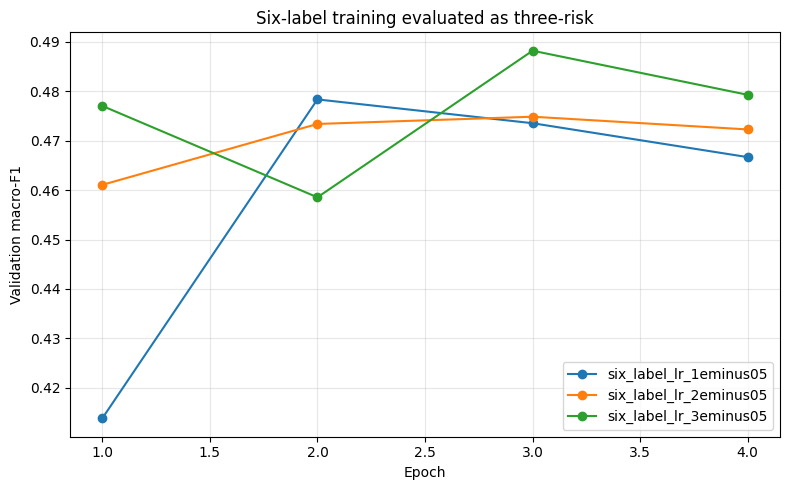

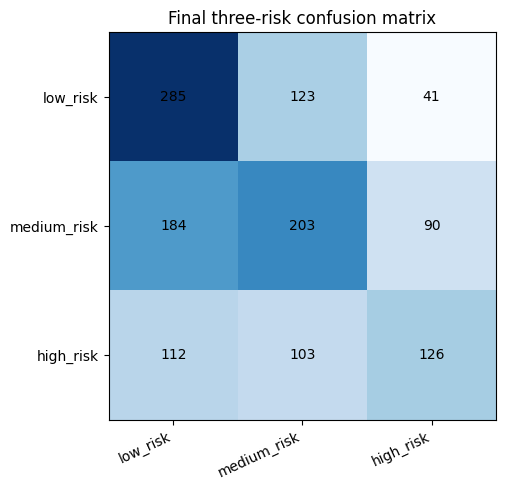

,confidence_bin,count,accuracy
0,"(0.0, 0.5]",347,0.389049
1,"(0.5, 0.6]",364,0.475275
2,"(0.6, 0.7]",263,0.501901
3,"(0.7, 0.8]",182,0.532967
4,"(0.8, 0.9]",84,0.726190
5,"(0.9, 1.0]",27,0.592593


,label,statement,six_label,risk_label,true_risk,predicted_risk,confidence,low_probability,medium_probability,high_probability
1076,barely-true,"Black Lives Matter, who are attacking law enfo...",2,1,medium_risk,high_risk,0.986037,0.005402,0.008561,0.986037
316,true,"Says a YouTube video shows Thomas DiMassimo, t...",5,0,low_risk,high_risk,0.980914,0.006416,0.012670,0.980914
11,barely-true,PolitiFact Texas says Congressman Edwards atta...,2,1,medium_risk,high_risk,0.980059,0.005734,0.014206,0.980059
1224,barely-true,Says President Obamas new immigration plan is ...,2,1,medium_risk,high_risk,0.978319,0.005754,0.015927,0.978319
386,half-true,Sherrod Brown and his special interest allies ...,3,1,medium_risk,high_risk,0.975110,0.008402,0.016488,0.975110
498,half-true,Jennifer Carrolls an outsider.,3,1,medium_risk,high_risk,0.943584,0.010586,0.045830,0.943584
249,half-true,Says a Ted Cruz ad has got me bull-dozing down...,3,1,medium_risk,high_risk,0.939939,0.014682,0.045379,0.939939
327,true,Sayvideo shows massive alligator strolling acr...,5,0,low_risk,high_risk,0.938348,0.022283,0.039369,0.938348
109,true,"The words subhuman mongrel, which Ted Nugent c...",5,0,low_risk,high_risk,0.916852,0.025729,0.057419,0.916852
123,barely-true,Neville Chamberlain told the British people: A...,2,1,medium_risk,high_risk,0.912958,0.022214,0.064828,0.912958


,claim_type,claim,low_probability,medium_probability,high_probability,risk_score,predicted_risk
0,sensational vague claim,Experts say the government is hiding the shock...,0.0264,0.1489,0.8247,0.8992,high_risk
1,neutral local claim,The city council approved a new recycling poli...,0.4792,0.3180,0.2028,0.3618,low_risk
2,specific number claim,The unemployment rate increased by 4 percent l...,0.5775,0.1891,0.2334,0.3280,low_risk
3,absolutist claim,Everyone knows this policy will completely des...,0.0505,0.6006,0.3489,0.6492,medium_risk
4,plain political claim,A politician said the programme cost more than...,0.1975,0.3871,0.4154,0.6090,high_risk
5,negation claim,The report did not say that taxes were increas...,0.3073,0.1721,0.5206,0.6067,high_risk
6,short claim,Crime doubled last year.,0.7357,0.1131,0.1512,0.2078,low_risk
7,longer claim,A recent interview claimed that the new policy...,0.3039,0.3843,0.3118,0.5040,medium_risk


,method,test_accuracy,test_macro_f1,high_risk_f1
0,direct_3risk_BERT argmax,0.471981,0.465831,0.424242
1,direct_3risk_BERT ordinal thresholds,0.438043,0.436584,0.418605
2,direct_3risk_BERT ordinal plus rules,0.438832,0.436971,0.421374
3,six_label_to_3risk_aggregate_probability_argmax,0.484609,0.474309,0.421405


Saved all results to: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/liar_6label_to_3risk_results


In [ ]:

# Cell 6: Reliability bins, error examples, stress tests, plots, and manifest.
confidence = test['risk_probs'].max(axis=1)
correct = (final_predictions == test['true_risk']).astype(int)
reliability_df = pd.DataFrame({'confidence': confidence, 'correct': correct})
reliability_df['confidence_bin'] = pd.cut(reliability_df['confidence'], bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
reliability_summary_df = reliability_df.groupby('confidence_bin', observed=False).agg(count=('correct', 'size'), accuracy=('correct', 'mean')).reset_index()
reliability_summary_df.to_csv(os.path.join(results_dir, 'table_11_reliability_bins.csv'), index=False)

error_df = test_df.copy().reset_index(drop=True)
error_df['true_risk'] = [risk_label_names[index] for index in test['true_risk']]
error_df['predicted_risk'] = [risk_label_names[index] for index in final_predictions]
error_df['confidence'] = confidence
error_df['low_probability'] = test['risk_probs'][:, 0]
error_df['medium_probability'] = test['risk_probs'][:, 1]
error_df['high_probability'] = test['risk_probs'][:, 2]
error_examples_df = error_df[correct == 0].sort_values('confidence', ascending=False).head(30)
error_examples_df[['label', 'statement', 'true_risk', 'predicted_risk', 'confidence', 'low_probability', 'medium_probability', 'high_probability']].to_csv(os.path.join(results_dir, 'table_12_high_confidence_errors.csv'), index=False)

def predict_claim(claim):
    encoded = tokenizer(claim, truncation=True, padding='max_length', max_length=max_sequence_length, return_tensors='pt')
    encoded = {key: value.to(device) for key, value in encoded.items()}
    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(**encoded).logits, dim=1).cpu().numpy()
    risk_probabilities = six_probabilities_to_risk_probabilities(probabilities)[0]
    score = float(0.5 * risk_probabilities[1] + risk_probabilities[2])
    argmax_label = int(np.argmax(risk_probabilities))
    threshold_label = int(labels_from_risk_scores(np.array([score]), best_medium, best_high)[0])
    final_label = threshold_label if selected_method == 'ordinal_thresholds' else argmax_label
    return {'low_probability': round(float(risk_probabilities[0]), 4), 'medium_probability': round(float(risk_probabilities[1]), 4), 'high_probability': round(float(risk_probabilities[2]), 4), 'risk_score': round(score, 4), 'predicted_risk': risk_label_names[final_label]}

stress_items = [
    ('sensational vague claim', 'Experts say the government is hiding the shocking truth about crime statistics.'),
    ('neutral local claim', 'The city council approved a new recycling policy on Tuesday.'),
    ('specific number claim', 'The unemployment rate increased by 4 percent last year.'),
    ('absolutist claim', 'Everyone knows this policy will completely destroy the economy.'),
    ('plain political claim', 'A politician said the programme cost more than originally planned.'),
    ('negation claim', 'The report did not say that taxes were increased for every household.'),
    ('short claim', 'Crime doubled last year.'),
    ('longer claim', 'A recent interview claimed that the new policy reduced waiting times, cut costs, and improved access for rural communities.'),
]
stress_rows = []
for claim_type, claim in stress_items:
    stress_rows.append({'claim_type': claim_type, 'claim': claim, **predict_claim(claim)})
stress_df = pd.DataFrame(stress_rows)
stress_df.to_csv(os.path.join(results_dir, 'table_13_stress_tests.csv'), index=False)

history_df = pd.read_csv(history_path)
plt.figure(figsize=(8, 5))
for run_name, group in history_df.groupby('run_name'):
    plt.plot(group['epoch'], group['risk_val_macro_f1'], marker='o', label=run_name)
plt.xlabel('Epoch')
plt.ylabel('Validation macro-F1')
plt.title('Six-label training evaluated as three-risk')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'figure_01_validation_macro_f1.png'), dpi=160)
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(final_matrix, cmap='Blues')
plt.title('Final three-risk confusion matrix')
plt.xticks(range(3), risk_label_names, rotation=25, ha='right')
plt.yticks(range(3), risk_label_names)
for row in range(3):
    for col in range(3):
        plt.text(col, row, final_matrix[row, col], ha='center', va='center')
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'figure_02_confusion_matrix.png'), dpi=160)
plt.show()

direct_path = os.path.join(project_root, 'model_training', 'claim_risk_results', 'table_10_test_ablation.csv')
comparison_rows = []
if os.path.exists(direct_path):
    direct_df = pd.read_csv(direct_path)
    for _, row in direct_df.iterrows():
        comparison_rows.append({'method': 'direct_3risk_' + str(row['method']), 'test_accuracy': row['test_accuracy'], 'test_macro_f1': row['test_macro_f1'], 'high_risk_f1': row['high_risk_f1']})
comparison_rows.append({'method': 'six_label_to_3risk_' + selected_method, 'test_accuracy': float(final_result_df.iloc[0]['test_accuracy']), 'test_macro_f1': float(final_result_df.iloc[0]['test_macro_f1']), 'high_risk_f1': float(final_result_df.iloc[0]['high_risk_f1'])})
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(os.path.join(results_dir, 'table_14_direct_vs_six_label_comparison.csv'), index=False)

manifest = {'created_at': datetime.now().isoformat(timespec='seconds'), 'task': 'train six LIAR labels and evaluate as three risk labels', 'base_model': base_model_name, 'learning_rates': learning_rates, 'max_epochs': max_epochs, 'batch_size': batch_size, 'max_sequence_length': max_sequence_length, 'selected_run': checkpoint['run_name'], 'selected_learning_rate': checkpoint['learning_rate'], 'selected_epoch': checkpoint['epoch'], 'selected_method': selected_method, 'selected_model_path': selected_model_path, 'results_dir': results_dir, 'figure_dir': figure_dir}
with open(os.path.join(results_dir, 'liar_6label_to_3risk_manifest.json'), 'w') as manifest_file:
    json.dump(manifest, manifest_file, indent=2)

display(reliability_summary_df)
display(error_examples_df.head(10))
display(stress_df)
display(comparison_df)
print('Saved all results to:', results_dir)


In [ ]:
# Cell 7: Six-label-to-three-risk stability check with three random seeds
# Responsibility: test whether the selected six-label setup is stable across random seeds.

six_seed_learning_rate = 3e-5
six_seed_epochs = 3
six_seed_values = [42, 123, 2025]

six_seed_results_path = os.path.join(
    results_dir,
    "table_15_six_label_seed_results.csv"
)

six_seed_summary_path = os.path.join(
    results_dir,
    "table_16_six_label_seed_summary.csv"
)

def count_trainable_parameters(model):
    trainable_parameters = 0
    total_parameters = 0

    for parameter in model.parameters():
        parameter_count = parameter.numel()
        total_parameters += parameter_count

        if parameter.requires_grad:
            trainable_parameters += parameter_count

    return trainable_parameters, total_parameters

def train_six_label_seed_model(seed_value):
    set_random_seed(seed_value)

    model = build_model()

    trainable_parameters, total_parameters = count_trainable_parameters(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=six_seed_learning_rate
    )

    total_steps = len(train_loader) * six_seed_epochs

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    best_validation_macro_f1 = -1.0
    best_validation_accuracy = 0.0
    best_epoch = 0

    best_model_path = os.path.join(
        experiment_dir,
        "six_label_seed_" + str(seed_value) + "_best_model.pt"
    )

    start_time = time.time()

    print("\n==================================================")
    print("Six-label seed run:", seed_value)
    print("Learning rate:", six_seed_learning_rate)
    print("Epochs:", six_seed_epochs)

    for epoch_index in range(six_seed_epochs):
        epoch_number = epoch_index + 1

        print("\nSeed:", seed_value, "| Epoch:", epoch_number, "/", six_seed_epochs)

        train_loss = train_one_epoch(
            model,
            optimizer,
            scheduler,
            loss_function,
            epoch_number
        )

        validation_results = evaluate_model(
            model,
            validation_loader
        )

        validation_true_risk = validation_results["true_risk"]
        validation_predictions = validation_results["risk_pred_aggregate"]

        validation_accuracy = accuracy_score(
            validation_true_risk,
            validation_predictions
        )

        validation_macro_f1 = f1_score(
            validation_true_risk,
            validation_predictions,
            average="macro"
        )

        print("  train loss:", round(train_loss, 4))
        print("  validation accuracy:", round(validation_accuracy, 4))
        print("  validation macro-F1:", round(validation_macro_f1, 4))

        if validation_macro_f1 > best_validation_macro_f1:
            best_validation_macro_f1 = validation_macro_f1
            best_validation_accuracy = validation_accuracy
            best_epoch = epoch_number

            torch.save({
                "seed": seed_value,
                "learning_rate": six_seed_learning_rate,
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "base_model_name": base_model_name,
                "six_label_names": six_label_names,
                "risk_label_names": risk_label_names,
                "decision_method": "aggregate_probability_argmax",
                "validation_accuracy": best_validation_accuracy,
                "validation_macro_f1": best_validation_macro_f1,
                "max_sequence_length": max_sequence_length,
                "trainable_parameters": trainable_parameters,
                "total_parameters": total_parameters,
            }, best_model_path)

            print("  saved new best seed model.")

        clear_memory()

    training_time_seconds = time.time() - start_time

    best_checkpoint = torch.load(
        best_model_path,
        map_location=device
    )

    best_model = build_model()
    best_model.load_state_dict(best_checkpoint["model_state_dict"])
    best_model.to(device)

    test_results_for_seed = evaluate_model(
        best_model,
        test_loader
    )

    test_true_risk = test_results_for_seed["true_risk"]
    test_predictions = test_results_for_seed["risk_pred_aggregate"]

    test_report = classification_report(
        test_true_risk,
        test_predictions,
        target_names=risk_label_names,
        output_dict=True,
        zero_division=0
    )

    result_row = {
        "seed": seed_value,
        "learning_rate": six_seed_learning_rate,
        "best_epoch": best_epoch,
        "validation_accuracy": best_validation_accuracy,
        "validation_macro_f1": best_validation_macro_f1,
        "test_accuracy": accuracy_score(test_true_risk, test_predictions),
        "test_macro_f1": f1_score(test_true_risk, test_predictions, average="macro"),
        "low_risk_f1": test_report["low_risk"]["f1-score"],
        "medium_risk_f1": test_report["medium_risk"]["f1-score"],
        "high_risk_f1": test_report["high_risk"]["f1-score"],
        "trainable_parameters": trainable_parameters,
        "total_parameters": total_parameters,
        "training_time_seconds": training_time_seconds,
        "best_model_path": best_model_path,
    }

    del model
    del best_model
    clear_memory()

    return result_row

six_seed_rows = []

for seed_value in six_seed_values:
    seed_result = train_six_label_seed_model(seed_value)
    six_seed_rows.append(seed_result)

    pd.DataFrame(six_seed_rows).to_csv(
        six_seed_results_path,
        index=False
    )

six_seed_results_df = pd.DataFrame(six_seed_rows)
six_seed_results_df.to_csv(
    six_seed_results_path,
    index=False
)

six_seed_summary_df = six_seed_results_df.agg({
    "validation_macro_f1": ["mean", "std"],
    "test_macro_f1": ["mean", "std"],
    "test_accuracy": ["mean", "std"],
    "high_risk_f1": ["mean", "std"],
    "training_time_seconds": ["mean", "std"],
}).T.reset_index()

six_seed_summary_df.columns = [
    "metric",
    "mean",
    "std"
]

six_seed_summary_df.to_csv(
    six_seed_summary_path,
    index=False
)

print("\nSix-label seed-level results:")
display(six_seed_results_df)

print("\nSix-label seed summary:")
display(six_seed_summary_df)

print("Saved seed results to:", six_seed_results_path)
print("Saved seed summary to:", six_seed_summary_path)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Six-label seed run: 42
Learning rate: 3e-05
Epochs: 3

Seed: 42 | Epoch: 1 / 3
  epoch 1 batch 100 loss 1.8495
  epoch 1 batch 200 loss 1.7957
  epoch 1 batch 300 loss 1.7102
  epoch 1 batch 400 loss 1.8297
  epoch 1 batch 500 loss 1.7514
  epoch 1 batch 600 loss 2.0336
  train loss: 1.7645
  validation accuracy: 0.4759
  validation macro-F1: 0.47
  saved new best seed model.

Seed: 42 | Epoch: 2 / 3
  epoch 2 batch 100 loss 1.2757
  epoch 2 batch 200 loss 1.8476
  epoch 2 batch 300 loss 1.6062
  epoch 2 batch 400 loss 1.4506
  epoch 2 batch 500 loss 1.6633
  epoch 2 batch 600 loss 1.4318
  train loss: 1.6023
  validation accuracy: 0.4743
  validation macro-F1: 0.4705
  saved new best seed model.

Seed: 42 | Epoch: 3 / 3
  epoch 3 batch 100 loss 1.4986
  epoch 3 batch 200 loss 1.3445
  epoch 3 batch 300 loss 1.3275
  epoch 3 batch 400 loss 1.2536
  epoch 3 batch 500 loss 1.2657
  epoch 3 batch 600 loss 0.9386
  train loss: 1.3289
  validation accuracy: 0.4813
  validation macro-F1: 0.

...


Six-label seed-level results:


,seed,learning_rate,best_epoch,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,low_risk_f1,medium_risk_f1,high_risk_f1,trainable_parameters,total_parameters,training_time_seconds,best_model_path
0,42,0.00003,3,0.481308,0.477997,0.472770,0.466817,0.520256,0.462332,0.417863,109486854,109486854,715.480783,/content/drive/MyDrive/UoP/COMP3000/fake-news-...
1,123,0.00003,2,0.501558,0.499387,0.473560,0.468251,0.536981,0.429204,0.438569,109486854,109486854,712.102021,/content/drive/MyDrive/UoP/COMP3000/fake-news-...
2,2025,0.00003,2,0.481308,0.475036,0.479874,0.464320,0.561922,0.433062,0.397976,109486854,109486854,713.376022,/content/drive/MyDrive/UoP/COMP3000/fake-news-...



Six-label seed summary:


,metric,mean,std
0,validation_macro_f1,0.484140,0.013287
1,test_macro_f1,0.466463,0.001989
2,test_accuracy,0.475401,0.003893
3,high_risk_f1,0.418136,0.020298
4,training_time_seconds,713.652942,1.706318


Saved seed results to: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/liar_6label_to_3risk_results/table_15_six_label_seed_results.csv
Saved seed summary to: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/liar_6label_to_3risk_results/table_16_six_label_seed_summary.csv


In [ ]:
# Cell 8: Print final six-label-to-three-risk model choice and save final candidate copy
# Responsibility: make the selected six-label model clear for product use and report writing.

six_label_selected_model_path = os.path.join(
    model_copy_dir,
    "liar_6label_to_3risk_selected_model.pt"
)

final_six_label_model_save_path = os.path.join(
    model_copy_dir,
    "final_six_label_to_3risk_bert_model.pt"
)

if not os.path.exists(six_label_selected_model_path):
    raise FileNotFoundError(
        "Selected six-label model was not found. Run the six-label training/model-selection cell first."
    )

six_label_checkpoint = torch.load(
    six_label_selected_model_path,
    map_location=device
)

shutil.copy2(
    six_label_selected_model_path,
    final_six_label_model_save_path
)

print("Final six-label-to-three-risk model candidate")
print("=" * 70)
print("model_role: six_label_to_3risk_final_candidate")
print("base_model:", base_model_name)
print("training_dataset: LIAR")
print("trained_output_labels:", six_label_names)
print("product_output_labels:", risk_label_names)
print("saved_model_path:", final_six_label_model_save_path)
print("source_model_path:", six_label_selected_model_path)
print("selected_run:", six_label_checkpoint.get("run_name", "not recorded"))
print("selected_learning_rate:", six_label_checkpoint.get("learning_rate", "not recorded"))
print("selected_epoch:", six_label_checkpoint.get("epoch", "not recorded"))
print("max_sequence_length:", max_sequence_length)
print("decision_method: aggregate six-label probabilities into low/medium/high, then argmax")
print("test_accuracy:", float(final_result_df.iloc[0]["test_accuracy"]) if "final_result_df" in globals() else "run final evaluation cell to print")
print("test_macro_f1:", float(final_result_df.iloc[0]["test_macro_f1"]) if "final_result_df" in globals() else "run final evaluation cell to print")
print("high_risk_f1:", float(final_result_df.iloc[0]["high_risk_f1"]) if "final_result_df" in globals() else "run final evaluation cell to print")
print("how_to_use_in_inference: load BERT checkpoint, get six softmax probabilities, sum them into three risk probabilities, then use argmax.")
print("=" * 70)
print("Saved final candidate model copy to:")
print(final_six_label_model_save_path)


Final six-label-to-three-risk model candidate
model_role: six_label_to_3risk_final_candidate
base_model: bert-base-uncased
training_dataset: LIAR
trained_output_labels: ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
product_output_labels: ['low_risk', 'medium_risk', 'high_risk']
saved_model_path: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/model_copy/final_six_label_to_3risk_bert_model.pt
source_model_path: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/model_copy/liar_6label_to_3risk_selected_model.pt
selected_run: six_label_lr_3eminus05
selected_learning_rate: 3e-05
selected_epoch: 3
max_sequence_length: 128
decision_method: aggregate six-label probabilities into low/medium/high, then argmax
test_accuracy: run final evaluation cell to print
test_macro_f1: run final evaluation cell to print
high_risk_f1: run final evaluation cell to print
how_to_use_in_inference: load BERT checkpoint, get six softmax pr